In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from scipy import stats


<center>

# گزارش تحلیل اثرگذاری هزینه‌های تبلیغات بر میزان فروش


</center>

---

**مدیریت محترم واحد فروش و بازاریابی**

با سلام و احترام،

این گزارش با هدف بررسی رابطه بین هزینه‌های تبلیغات و میزان فروش تهیه شده است. در این تحلیل داده‌های مربوط به سه رسانه تبلیغاتی شامل تلویزیون، رادیو و روزنامه مورد بررسی قرار گرفته‌اند و تأثیر هر یک بر میزان فروش تحلیل شده است.

لازم به ذکر است که تمامی مقادیر مربوط به هزینه‌های تبلیغات بر حسب دلار در نظر گرفته شده‌اند.


In [34]:
path = r"C:\Users\Abbas\Desktop\انجام پروژه\پروژه دوره آمار و ریاضیات تحلیل_گر داده\advertising_Dataset.csv"
df = pd.read_csv(path)
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

cols = ['TV', 'Radio', 'Newspaper', 'Sales']
data_stats = df[cols]

summary_stats = pd.DataFrame(index=cols)
summary_stats['count'] = data_stats.count()
summary_stats['missing_values'] = data_stats.isnull().sum()
summary_stats['mean'] = data_stats.mean()
summary_stats['median'] = data_stats.median()
summary_stats['mode'] = data_stats.mode().iloc[0]
summary_stats['variance'] = data_stats.var()
summary_stats['std'] = data_stats.std()
summary_stats['min'] = data_stats.min()
summary_stats['max'] = data_stats.max()

Q1 = data_stats.quantile(0.25)
Q3 = data_stats.quantile(0.75)
IQR = Q3 - Q1
summary_stats['outliers'] = ((data_stats < (Q1 - 1.5 * IQR)) | (data_stats > (Q3 + 1.5 * IQR))).sum()

summary_stats


,count,missing_values,mean,median,mode,variance,std,min,max,outliers
TV,200,0,147.0425,149.75,17.2,7370.949893,85.854236,0.7,296.4,0
Radio,200,0,23.2640,22.90,4.1,220.427743,14.846809,0.0,49.6,0
Newspaper,200,0,30.5540,25.75,8.7,474.308326,21.778621,0.3,114.0,2
Sales,200,0,14.0225,12.90,9.7,27.221853,5.217457,1.6,27.0,0


<center>

### قبل از تحلیل نیاز بود شناخت کلی از داده‌ها به دست آوریم

</center>

با بررسی اولیه بر روی داده‌ها و بعد از به دست آوردن مقادیر توصیفی (میانگین، واریانس، چارک‌ها، دامنه تغییرات، معیار انحراف) مورد توجه قرار گرفتند.

طبق این معیارها متغیر تلویزیون نشان داد که میزان هزینه در این بخش، پراکندگی قابل توجهی وجود دارد و ممکن است نقش مهمی در توضیح تغییرات فروش داشته باشد.


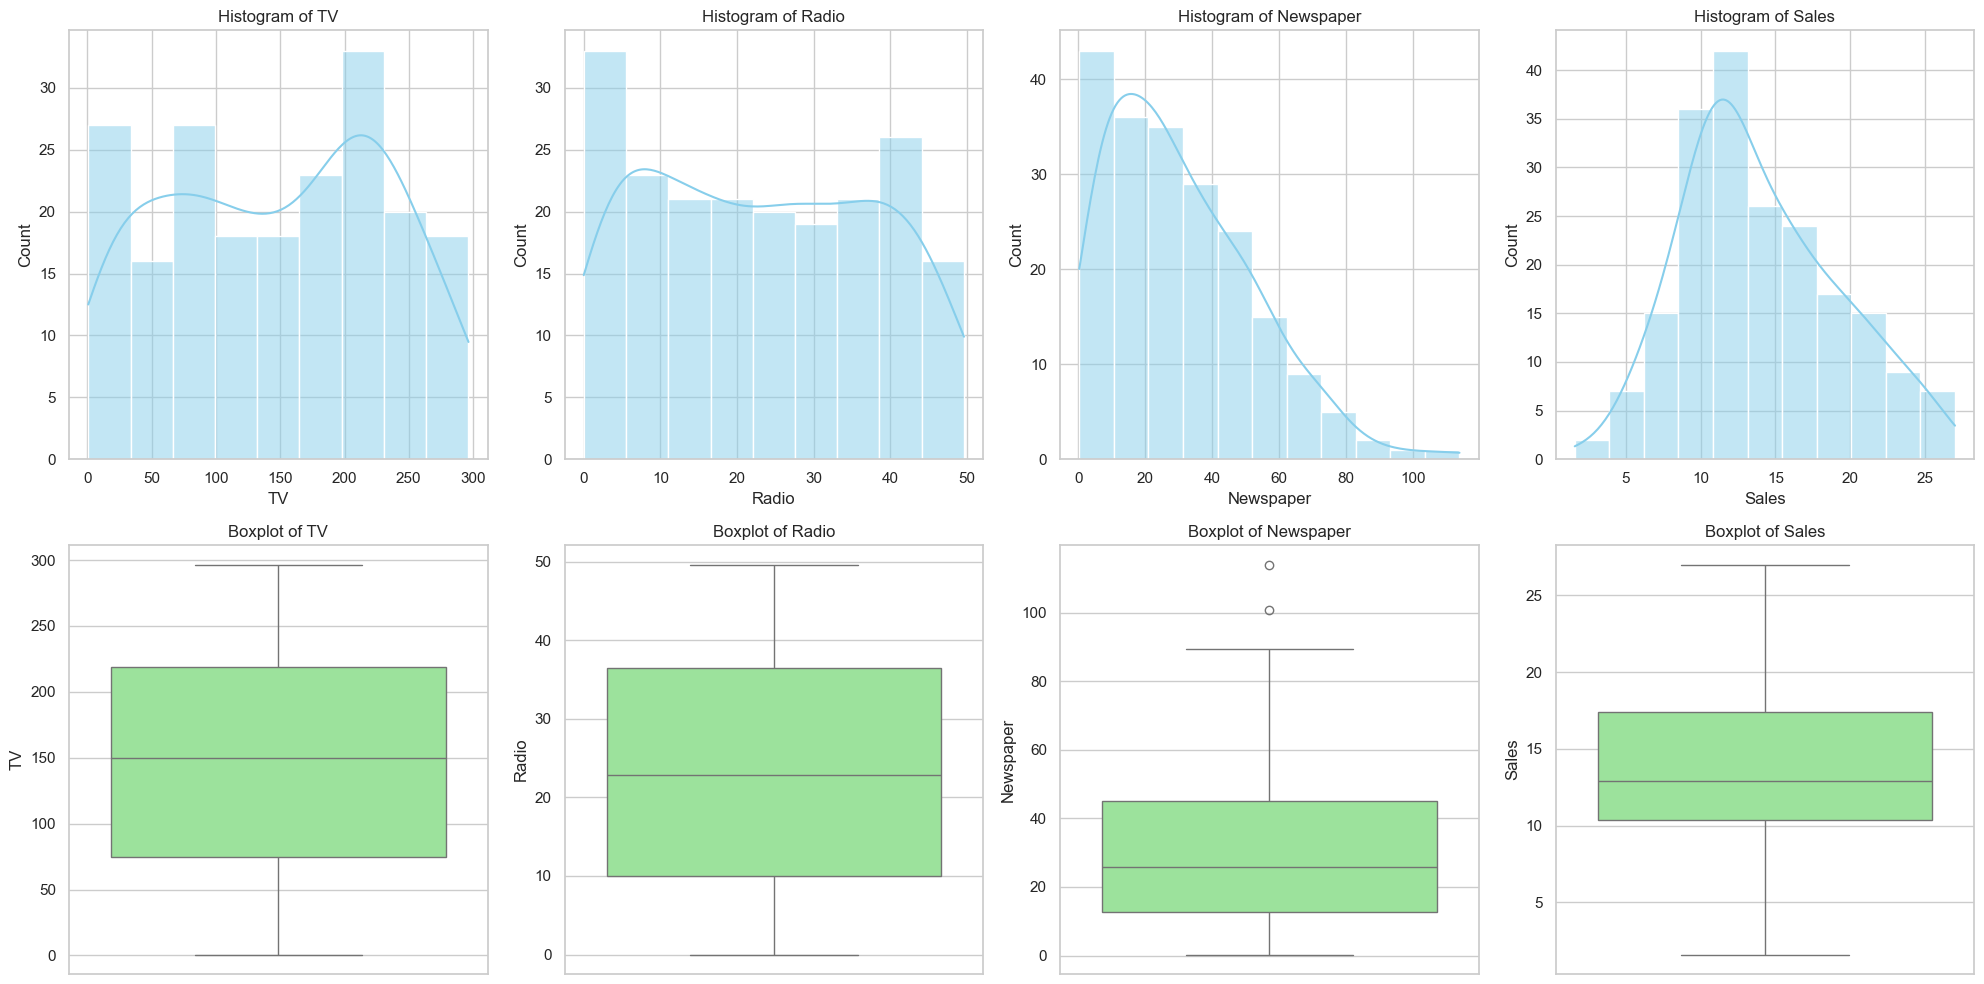

In [24]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(cols):
    sns.histplot(data_stats[col], ax=axes[0, i], kde=True, color='skyblue')
    axes[0, i].set_title(f'Histogram of {col}')
    sns.boxplot(y=data_stats[col], ax=axes[1, i], color='lightgreen')
    axes[1, i].set_title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()


<center>

### همانطور که در نمودارها می‌بینید

</center>

در این تحلیل مشخص شد داده‌ها از نظر کلی قابل تحلیل هستند و مشکل جدی مانند نبود داده‌ها یا مقادیر گمشده در آن دیده نمی‌شود. همچنین بررسی نقاط پرت نشان داد که اگرچه مقادیر در متغیرها نسبت به یکدیگر متفاوت هستند، اما این اختلاف‌ها غیرمنطقی نیستند که کل داده‌ها را بی‌اعتبار کنند.

این نتایج نشان می‌دهد که برای تحلیل‌های بعدی، به‌ویژه در مدل‌سازی، باید توجه ویژه‌ای به رفتار متغیر روزنامه داشت.


In [25]:
features = ['TV', 'Radio', 'Newspaper']
data_pca_unstd = df[features]
cov_matrix_unstd = data_pca_unstd.cov()
cov_matrix_unstd


,TV,Radio,Newspaper
TV,7370.949893,69.862492,105.919452
Radio,69.862492,220.427743,114.496979
Newspaper,105.919452,114.496979,474.308326


بعد از این رفتار متغیرها بررسی شد، برای درک بهتر رابطه میانگین بین متغیرها نیاز بود از تحلیل مؤلفه‌های اصلی استفاده کنیم.

در این مرحله هدف این بود که مشخص شود آیا می‌توان اطلاعات مربوط به کانال‌های تبلیغاتی را در چند مؤلفه‌ اصلی خلاصه کرد یا خیر.


**در ایتدا تحلیل مؤلفه‌های اصلی روی داده های خام انجام شد ،که در جدول بالا مشاهده میکنید** 
مقدار کوواریانس مربوط به متغییر تلویزیون بزرگ تر است نسبت به دو متغییر دیگر، به خاطر همین بیشترین پراکندگی مربوط به همین متغییر است و همچنین کوواریانس  هر دو متغییر نسبت به تلویزیون مقادیر مثبت هستند اما شدت آن ها نسبت متغییر تلویزیون بسیار کمتر است


In [26]:
pca_unstd = PCA()
pca_unstd.fit(data_pca_unstd)

pca_variance_unstd = pd.DataFrame({
    'Explained Variance Ratio': [f"{v*100:.2f}%" for v in pca_unstd.explained_variance_ratio_]
}, index=['Pc1', 'Pc2', 'Pc3'])

pca_variance_unstd


,Explained Variance Ratio
Pc1,91.42%
Pc2,6.40%
Pc3,2.19%


**طبق مقادیر ویژه به دست آمد**

مؤلفه‌ اول بسیار بزرگ تر از دو مؤلفه‌ دیگر است و تقریبا به طور کامل تحت تاثیر متغیرر تلویزیون قرار دارد و در مؤلفه‌ دوم بیشترین ضریب بوط به روزنامه می باشد که بخش کمتری از تغییرات را توضیح میدهد و در مؤلفه‌ سوم بیشترین ضریب مربوط به رادیو است که کمترین سهم را در پراکندگی توضیح میدهد .

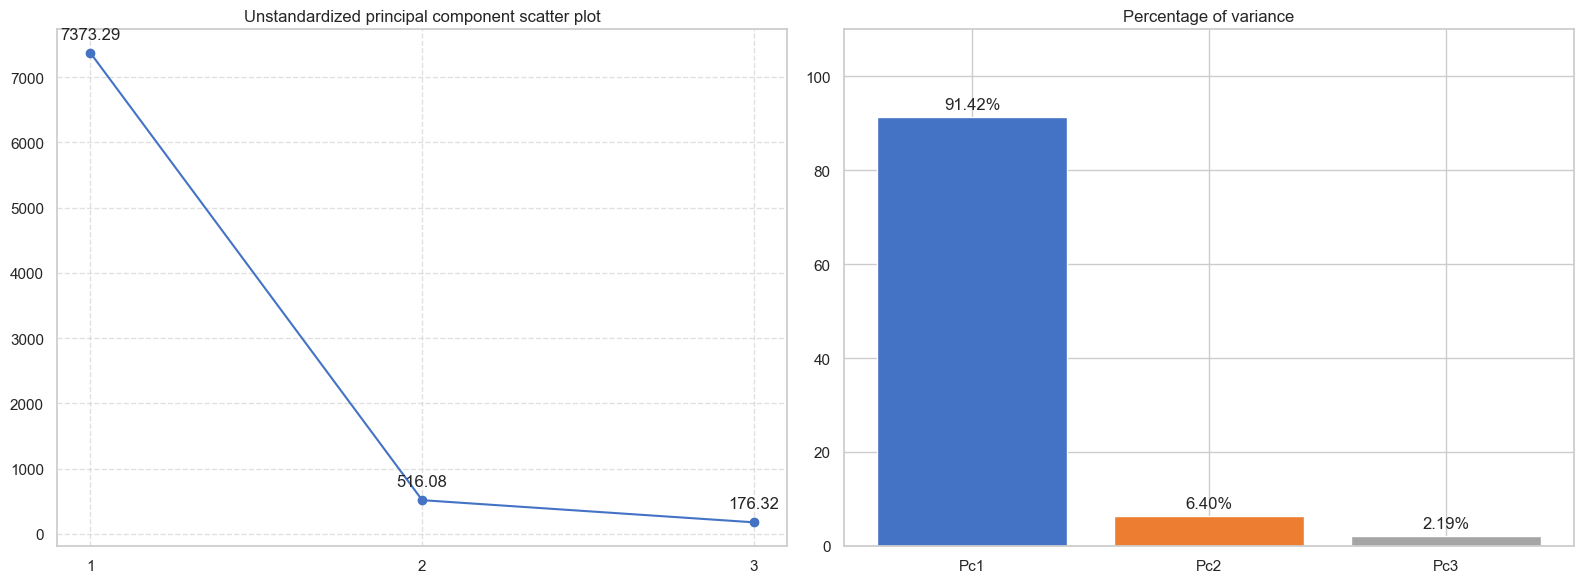

In [27]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

eigenvalues_unstd = pca_unstd.explained_variance_
ax1.plot([1, 2, 3], eigenvalues_unstd, marker='o', color='#4472C4')
for i, val in enumerate(eigenvalues_unstd):
    ax1.annotate(f'{val:.2f}', (i+1, val), textcoords="offset points", xytext=(0,10), ha='center')
ax1.set_title('Unstandardized principal component scatter plot')
ax1.set_xticks([1, 2, 3])
ax1.grid(True, linestyle='--', alpha=0.6)

ratios_unstd = pca_unstd.explained_variance_ratio_ * 100
bars = ax2.bar(['Pc1', 'Pc2', 'Pc3'], ratios_unstd, color=['#4472C4', '#ED7D31', '#A5A5A5'])
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', ha='center', va='bottom')
ax2.set_title('Percentage of variance')
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()


**و در نمودار  نیز میشود مشاهده کرد که مؤلفه‌ اول بسیار بیشتر از مولفه دوم  و سوم است و بعد از افت شدیدی را تجربه  میکند**

که نشان دهنده آن است که بخش عمده ای از اطلاعات در مؤلفه‌ اول است .
 که اگر هدف کاهش ابعاد باشد میتوان به جای سه متغییر ، از دو مؤلفه‌ اول اصلی استفاده کرد، به این معنی که اگر معیار حفظ  تقریبا 90%  اطلاعات باشد یک مؤلفه‌ اول اصلی کافیست . 
برای دقت بیشتر میتوان از دو مؤلفه‌ اول و دوم هم استفاده کرد چون تقریبا 97% را پوشش می دهد.
در این مدل نمیتوان متغییر هارا با هم مقایسه کرد.


**بنابراین برای جلوگیری از غلبه یک متغییر بر تحلیل(واریانس تلویزیون بسیار بیشتر از دو متغییر دیگر بود) ، داده های سه متغییر استانداردسازی شدند .**

In [28]:
scaler = StandardScaler()
data_std = pd.DataFrame(scaler.fit_transform(data_pca_unstd), columns=features)
cov_matrix_std = data_std.cov()
cov_matrix_std


,TV,Radio,Newspaper
TV,1.005025,0.055084,0.056933
Radio,0.055084,1.005025,0.355883
Newspaper,0.056933,0.355883,1.005025


که باعث شد متغییر ها در مقیاس قابل مقاسیه قرار گیرند و هر متغییر براساس الگو واقعی خود در تحلیل گنجانده شود نه صرفا به خاطر بزرگ بود مقدار عددی آن متغییر .
همانگونه که در جدول مشاهده میکنید با محاصبه ماتریس همبستگی ، رابطه متغییر های تلویزیون و رادیو و رابطه متغییر های تلویزیون و روزنامه بسیار کم شده است ، اما همبستگی رادیو و زورنامه نسبت به دو رابطه دیگر قوی تر است و میتوان گفت این دو متغییر با یکدیگر رابطه مثبت دارند .


In [29]:
pca_std = PCA()
pca_std.fit(data_std)

pca_variance_std = pd.DataFrame({
    'Explained Variance Ratio': [f"{v*100:.2f}%" for v in pca_std.explained_variance_ratio_]
}, index=['Pc1', 'Pc2', 'Pc3'])

pca_variance_std


,Explained Variance Ratio
Pc1,45.70%
Pc2,32.78%
Pc3,21.53%


با به دست آوردن مقادیر ویژه **در حالت استانداردسازی شده**
 مؤلفه‌ اول 45.70% از تغییرات را توضیح میدهد 
نتایج مؤلفه‌های اصلی نشان می دهد که پس از استاندارد سازی ، سهم تلویزیون در تشکیل مؤلفه‌ کاهش یافته  و داده به صورت متعادل تری بین متغییر ها توزیع شده است .

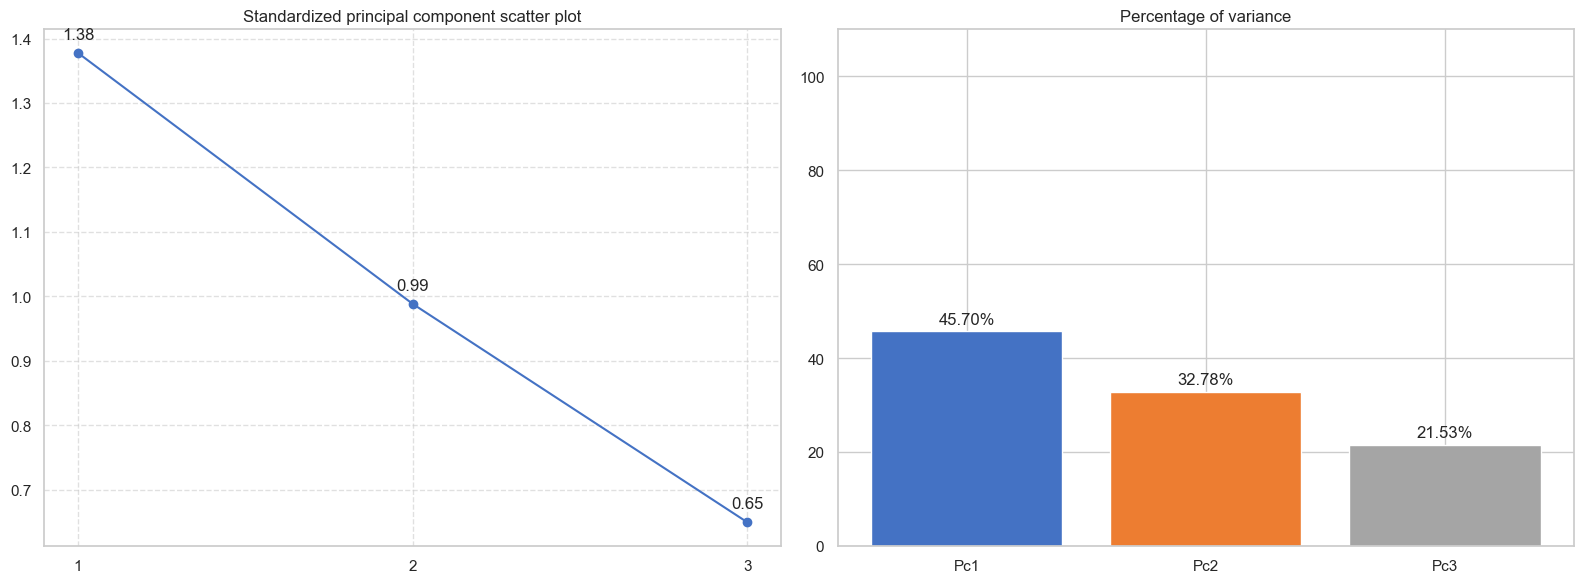

In [30]:
features = ['TV', 'Radio', 'Newspaper']

scaler = StandardScaler()
data_std = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

pca_std = PCA()
pca_std.fit(data_std)

eigenvalues_std = pca_std.explained_variance_
ratios_std = pca_std.explained_variance_ratio_ * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot([1, 2, 3], eigenvalues_std, marker='o', color='#4472C4')
for i, val in enumerate(eigenvalues_std):
    ax1.annotate(f'{val:.2f}', (i+1, val), textcoords="offset points", xytext=(0,10), ha='center')
ax1.set_title('Standardized principal component scatter plot')
ax1.set_xticks([1, 2, 3])
ax1.grid(True, linestyle='--', alpha=0.6)

bars = ax2.bar(['Pc1', 'Pc2', 'Pc3'], ratios_std, color=['#4472C4', '#ED7D31', '#A5A5A5'])
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1, f'{height:.2f}%', ha='center', va='bottom')
ax2.set_title('Percentage of variance')
ax2.set_ylim(0, 110)

plt.tight_layout()
plt.show()


به خاطر همین همانطور که در نمودارنیز میبینید میتوان بهتر تشخیص داد که هر متغییر چه نقشی در ساختار کلی شرکت دارد .
و اگر هدف کاهش ابعاد باشد ، استفاده از دو مؤلفه‌ اصلی منطقی تر است .


**در ادامه گزارش برای پیش بینی بهتر آینده یا ساخت مدل پیش بینی کننده ، تا بتوانیم رابطه میان سه متغییر را با فروش بسنجیم و به صورت عددی و قابل توضیح بررسی کنیم از تحلیل رگرسیون چند متغییره استفاده میکنیم .**

**مدل رگرسیون به شرح زیر است**

**Sales = 2.9502+(0.0459(Tv)) + (0.1882(Radio)) - (0.001(newspaper))**

بر اساس این  مدل مقدار اولیه نشان میدهد که هزینه تبلیغات در هر سه کانال اگر صفر باشد  مقدار پایه فروش 
برابر است با  2.9502 است .
و ضرایب هر متغییر نشان میدهد که در صورت افزایش یک واحد هزینه تبلیغات ،درصورتی که دو متغییر دیگر ثابت باشند حدودا نسبت به ضرایت متغییر واحد افزایش می یابد .
یک نکته اینکه ضریب روزنامه نزدیک به صفر است که نشان میدهد در این مدل ، تبلیغات اثر چندانی بر فروش ندارد 
بر اساس ضرایب مدل و مقادیر سطح معناداری ،  دو متغیر تلویزیون و رادیو نقش اصلی را در پیش‌بینی فروش ایفا می‌کنند و متغیر روزنامه اثر قابل‌توجهی نشان نمی‌دهد.


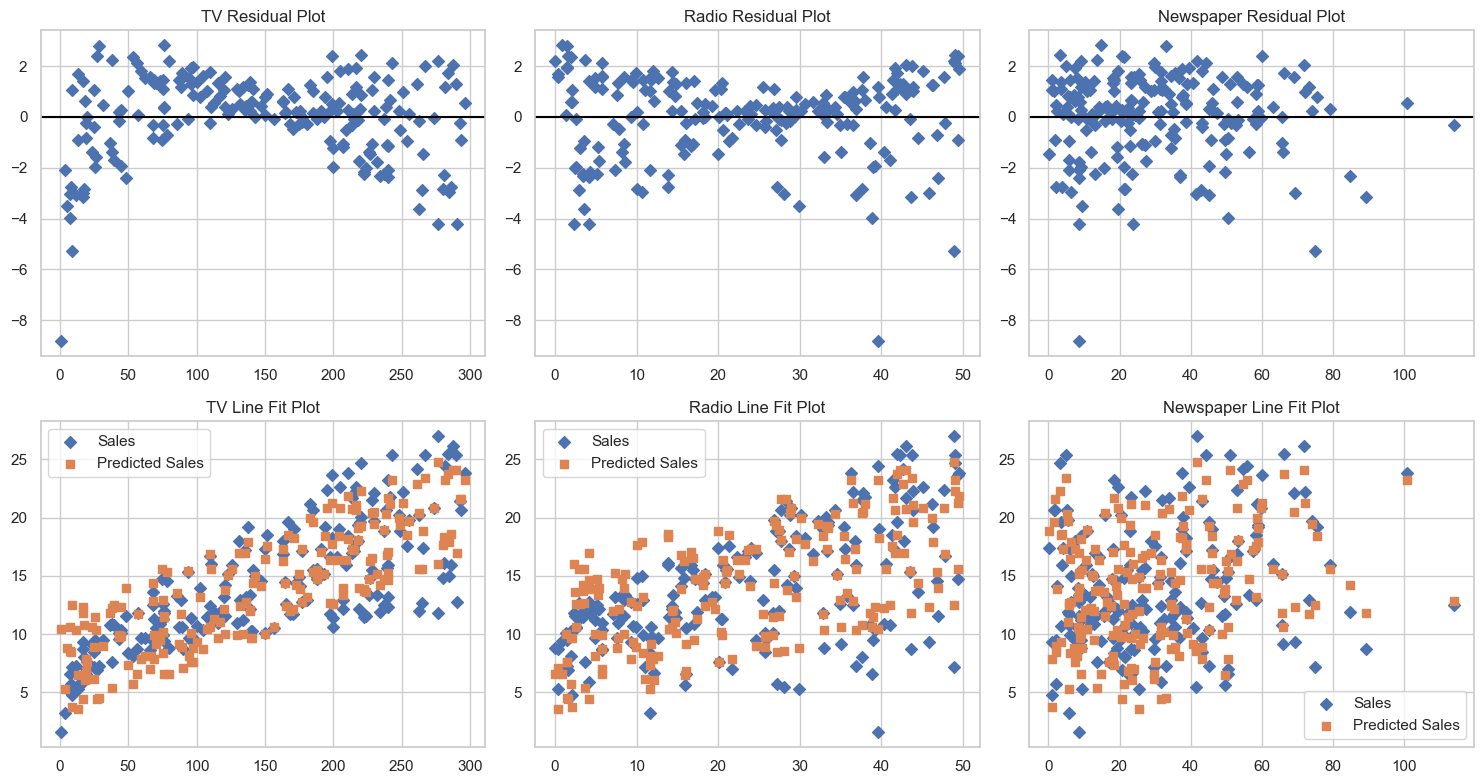

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.897
Model:                            OLS   Adj. R-squared:                  0.896
Method:                 Least Squares   F-statistic:                     570.3
Date:                Sat, 06 Jun 2026   Prob (F-statistic):           1.58e-96
Time:                        09:10:57   Log-Likelihood:                -386.18
No. Observations:                 200   AIC:                             780.4
Df Residuals:                     196   BIC:                             793.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          2.9389      0.312      9.422      0.0

In [32]:
X = sm.add_constant(df[['TV', 'Radio', 'Newspaper']])
model = sm.OLS(df['Sales'], X).fit()
p = model.predict(X)
r = df['Sales'] - p

plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
plt.scatter(df['TV'], r, marker='D')
plt.axhline(0, color='black')
plt.title('TV Residual Plot')

plt.subplot(2, 3, 2)
plt.scatter(df['Radio'], r, marker='D')
plt.axhline(0, color='black')
plt.title('Radio Residual Plot')

plt.subplot(2, 3, 3)
plt.scatter(df['Newspaper'], r, marker='D')
plt.axhline(0, color='black')
plt.title('Newspaper Residual Plot')

plt.subplot(2, 3, 4)
plt.scatter(df['TV'], df['Sales'], marker='D', label='Sales')
plt.scatter(df['TV'], p, marker='s', label='Predicted Sales')
plt.legend()
plt.title('TV Line Fit Plot')

plt.subplot(2, 3, 5)
plt.scatter(df['Radio'], df['Sales'], marker='D', label='Sales')
plt.scatter(df['Radio'], p, marker='s', label='Predicted Sales')
plt.legend()
plt.title('Radio Line Fit Plot')

plt.subplot(2, 3, 6)
plt.scatter(df['Newspaper'], df['Sales'], marker='D', label='Sales')
plt.scatter(df['Newspaper'], p, marker='s', label='Predicted Sales')
plt.legend()
plt.title('Newspaper Line Fit Plot')

plt.tight_layout()
plt.show()

print(model.summary())


**تحلیل کلی نمودارهای برازش (ردیف پایین) و خط (ردیف بالا)**
در نمودارهای برازش، می‌بینیم که مدل برای تلویزیون و رادیو پیش‌بینی نسبتاً خوبی انجام داده است، چون نقاط پیش‌بینی‌شده به مقادیر واقعی فروش نزدیک هستند. اما در مورد روزنامه، رابطه مشخص و قوی دیده نمی‌شود.
در نمودارهای خطا نیز بیشتر نقاط نزدیک عدد صفر قرار دارند. این یعنی اختلاف بین فروش واقعی و فروش پیش‌بینی‌شده زیاد نیست و مدل در کل عملکرد قابل قبولی دارد. فقط چند خطای بزرگ دیده می‌شود که تعدادشان کم است.
پس به طور کلی، مدل برای پیش‌بینی فروش مناسب است و تلویزیون و رادیو نقش مهم‌تری نسبت به روزنامه دارند.


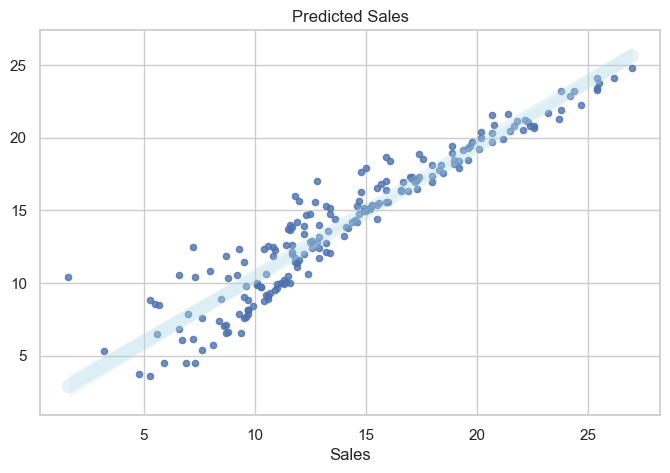

In [33]:
plt.figure(figsize=(8, 5))
sns.regplot(x=df['Sales'], y=p, scatter_kws={'s': 20}, line_kws={'color': 'lightblue', 'lw': 10, 'alpha': 0.3})
plt.title('Predicted Sales'); plt.show()


**و در نمودار پیش بینی فروش که مشاهده میکنید تمرکز داده در سمت چپ نشان دهنده رابطه مثبت و صعودی است و نقطه دور افتاده در سمت راست تاثیر جزئی در خط روند داشته است**